FILTRI CONVOLUZIONALI CON OPENCV

In una giornata di nebbia i contorni delle cose sfumano
In computer vision a volta si vuole creare quella nebbia artificiale oppure al contraria vogliamo rendere tutto più nitido.
Questo tecnica utilzza il kernel, non sono solo filtri estetici tipo istagram, ma strumenti di precisoine per preparare i dati per i nostri modelli di Deep Learning

- Il concetto di kernel e smothing:come ammorbidire un'immagine per togliere il rumore
- Concetto di sharpening tramite la tecnica della sotrazione del segnale per estrarre dettagli che sembravano perduti
- cv2.filtre2D per creare qualsiasi filtro

Perchè a volte rendere un'immagine meno nitida è la scelta migliore

Smoothin e Blurring
Riuzione del rumore e ammorbidimento dei contrasti.
Smoothing e Blurring sono tecniche di elaborazioni immagini per ridurre rumore, dettagli, fino a disturni visivi, mediando dei pixel con quelli vicini. In inglese sono usati quasi come sinonimi, anche se 'smoothing' è il termine più generale e 'blurring' è l'effetto visivo risultante (l'immagine appare sfocata)
Ogni tecnica applica un 'kernel' (una piccola matrice ed 3x3 o 5x5) che scorre sull'immagine e ricalcola ogni pixel come funzione dei pixel vicini.
Il Blurring è un'operazione fondamentale che permette di ridurre il rumore e i dettagli irrilevanti prima di fasi di processing più complesse.
Si base sull'applicazione di un kernel che agisce come un operatore di media locale sui pixel circostranti.
Immagina un sensore fotografico che lavora di notte, le immagini sono piene di puntini bianchi e neri, che chiamiamo rumore elettronico, se diamo questa immagine sporta ad una netre neurale potrebbe confondere una granello di polvere per una caratteristiche importante. Il Blurring agisce come un setaccio, elimina le piccole imperfezioni e lascia passare solo quelle grandi e seìignificative.

Ma come avviene, tecnicamente, questo processo di ammorbidimento?

Il Kernel e la Sfocatura
Meccanismi di integrazione spaziale
Il protgonista assoluto è il kernel, pensalo come una piccola griglia che scorre sopra l'immagine come una lente di ingrandimento
* Il kernel lineare è una matrice numeri di dimensioni dispari che scorre sull'immagine per calcolare il nuovo valore del pixel centrale (media dei vicini).
* Il Blur a MEdia (Averagin) assegna pesi uguali a ogni pixel nel vicinato, agendo come un filtro passa-basso grezzo (da più importanza ai pixel vicini e meno a quelli più lontani)
* Il Blur Gaussiano utilzza una distribuzione a campana dove i pixel più vicini al centro hanno un'influenza maggiore. Risultato più naturale, meno 'a blocchi' rispetto  all'averaging. standard per rimuovere rumore prima di altre elaborazioni
* Median Blur: sostituisce ogni pixel con la mediana dei pixel vicini invece della media. Molto efficace contro il rumore 'sale e pepe' (pixel isolati completamente sbagliati) perchè la mediana ignora outlier estremi. Usato spesso in preprocesing di scansione sporche.
* Bilateral Filtre: il più sofisticato, sfoca ma preserva i bordi netit. Considera sia la distanzia spaziale si ala differenza di colore/intensità tra i pixel. Costoso computazionalmente, ma è quello che vuoi se devi ridurre rumore mantenendo testo o contorni leggibili


Questo approccio è molto utilzzato perchè tende a non impastare i colori

Come gestiamo questo con OpenCV?

Implementazioni con OpenCV
cv2.blur: applica un semplice filtro di media. E' la scelta più veloce ma tende a rendere i bordi eccessivamente impastati.
cv2.GaussianBlur: utilzza un kernel calcolato secodno la funzione gaussiana. Risulta più naturale alla vista umana e preserva meglio le linee
Dimensioni del Kernel: le dimensioni devono essere numeri interi positivi e dispari per identificare univocamente il pixel centrale di ancoraggio.

Analisi dei Pesi del Blurring
Differenza tra Media e Gaussiana

In un filtro media 3x3, ogni valore del kernel è pari a 1/9, creando una distribuzione uniforme del contributo luminoso. La somma di tutti otteniamo 1, ed è questa la nostra conservazione dell'energia (1/9+1/9+1/9+1/9+1/9+1/9+1/9+1/9+1/9=1). L'immagine non diventa nè più chiara nè più scura, cambia solo la distribuzione locale della luce.

Nella Gaussiana, i pesi decadono esponenzialmente dal centro, riducendo gli artefatti di ringing tipici dei filtri rettangolari. Questo evita un effetto comune chiamnato ringhing, strani aloni intorno agli oggetti quando usiamo filtri troppo agressivi.

Ora che sappiamo come sfuocare, facciamo il percorso inverso, come facciamo a rendere tutto più nitido?

Sharpening dell'Immagine (arte di enfatizzare i contrasti)
Enfatizzare i dettagli e aumentare la nitidezza
Lo sharpening mira a invertire parzialmente l'effetto del blurring, rendendo i bordi e le texture più definiti.
Non si tratta di crare nuova informazione (che non esiste), ma di manipolare il segnale esistente per aumentare il constrasto locale. rendiamo il nero più nero ed i bianchi più biachi, proprio dove si toccano, questo inganna l'occhio umano e gli algoritmi, percependo una nitidezza maggiore.

Il trucco per farlo è semplicissimo, si basa sulla sottrazione.

Sottrazione del Segnale
Unsharp Masking (maschera non nitida) e derivete
Prendiamo l'immagine originale e ne creiamo una versione sfuocata (con blurring) poi sottraiamo all'immagine originale l'immagine sfuocata. Restano solo i dettagli fini, i bordi, le rugosita. Se prendiamo questi dettagli e li sommiamo all'immagine originale, otteniamo lo sharpening, togliamo la massa informa per far emergere gli elementi
* Il concetto base prevede di isolare le alte frequenze dell'immagine tramite sottrazione di una versione sfuocata dell'originale.
* La differenza tra immagine originale e immagine blurrata rappresenta i dettagli fini e i conterni netti
* Sommando questa differenza all'immagine originale, otteniamo una versione con bordi marcatamente accentuati.
* Un kernel di sharpening tipico presenta un valore centrale molto alto circondato da valori negativi che creano contrasto.




[*] Recupero immagine da: https://picsum.photos/1200/800


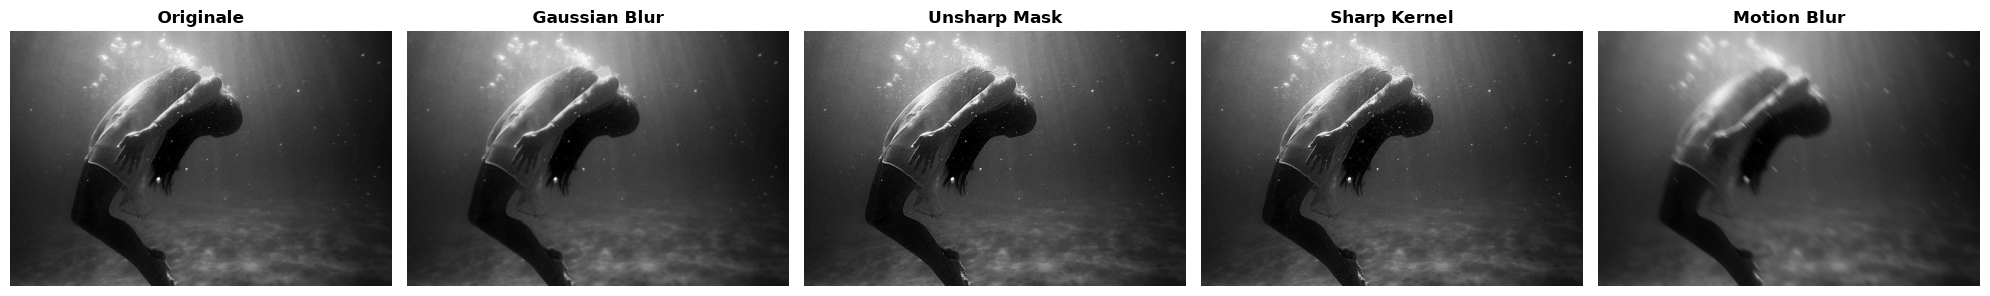

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

# Best Practice 2026: Configurazione ambiente per Deep Learning Preprocessing
os.environ["KERAS_BACKEND"] = "torch"

def load_image_from_url(url: str) -> np.ndarray:
    """
    Scarica un'immagine da internet e la converte in formato BGR per OpenCV.
    """
    print(f"[*] Recupero immagine da: {url}")
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        # Conversione dei byte in array NumPy e decodifica OpenCV
        img_array = np.frombuffer(response.content, np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        if img is None:
            raise ValueError("Errore nella decodifica dell'immagine.")
        return img
    except Exception as e:
        print(f"[-] Errore critico: {e}")
        return None

def process_vision_filters(image_url: str):
    # 0. CARICAMENTO DA URL
    img_bgr = load_image_from_url(image_url)
    
    if img_bgr is None:
        return

    # Conversione in RGB per Matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # --- 1. SMOOTHING (SFOCATURA) ---
    # Kernel di Media: assegna peso 1/N a ogni pixel nel vicinato.
    blur_avg = cv2.blur(img_rgb, (5, 5))

    # Blur Gaussiano: usa una distribuzione normale per preservare meglio le strutture.
    blur_gauss = cv2.GaussianBlur(img_rgb, (5, 5), 0)

    # --- 2. SHARPENING (NITIDEZZA) ---
    # Metodo 1: Unsharp Masking
    # Formula: Risultato = Originale + (Originale - Sfocata) 
    gaussian_mask = cv2.GaussianBlur(img_rgb, (9, 9), 10.0)
    # Formula applicata: 1.5 * Originale - 0.5 * Sfocata.
    img_sharp_sub = cv2.addWeighted(img_rgb, 1.5, gaussian_mask, -0.5, 0)

    # Metodo 2: Kernel di Sharpening Diretto (Matrice di Convoluzione)
    kernel_sharp = np.array([[ 0, -1,  0],
                             [-1,  5, -1],
                             [ 0, -1,  0]], dtype=np.float32)
    img_sharp_kern = cv2.filter2D(img_rgb, -1, kernel_sharp)

    # --- 3. KERNEL PERSONALIZZATO (MOTION BLUR) ---
    size = 15
    kernel_motion = np.zeros((size, size))
    np.fill_diagonal(kernel_motion, 1)
    kernel_motion /= size  # Normalizzazione per evitare sovraesposizione
    
    img_motion = cv2.filter2D(img_rgb, -1, kernel_motion)

    # --- VISUALIZZAZIONE ---
    titles = ['Originale', 'Gaussian Blur', 'Unsharp Mask', 'Sharp Kernel', 'Motion Blur']
    images = [img_rgb, blur_gauss, img_sharp_sub, img_sharp_kern, img_motion]

    plt.figure(figsize=(20, 8))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i])
        plt.title(titles[i], fontsize=12, fontweight='bold')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Esempio con un'immagine casuale ad alta risoluzione
    test_url = "https://picsum.photos/1200/800"
    process_vision_filters(test_url)